# Compas Analysis - Natchapa Aunkay

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Filter warnings
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

In [2]:
# Load dataset from GitHub
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape[0]

7214

In [3]:
# View first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# Filter dataset based on COMPAS criteria
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime columns to category
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].cat.categories if x != "Caucasian"],
    ordered=False
)

# Make Male the reference first
df["gender_factor"] = df["sex"].replace({"Female": "Female", "Male": "Male"})
df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],
    ordered=False
)

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
# Summary of age category
df["age_cat"].value_counts(dropna=False)

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Summary of race
df["race"].value_counts(dropna=False)

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
print("Black defendants: {:.2f}%".format(3175 / 6172 * 100))
print("White defendants: {:.2f}%".format(2103 / 6172 * 100))
print("Hispanic defendants: {:.2f}%".format(509 / 6172 * 100))
print("Asian defendants: {:.2f}%".format(31 / 6172 * 100))
print("Native American defendants: {:.2f}%".format(11 / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Summary of score_text
df["score_text"].value_counts(dropna=False)

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Cross-tab of sex and race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Summary of sex
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


In [14]:
print("Men: {:.2f}%".format(4997 / 6172 * 100))
print("Women: {:.2f}%".format(1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# Number of people with two-year recidivism
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
# Percentage with two-year recidivism
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

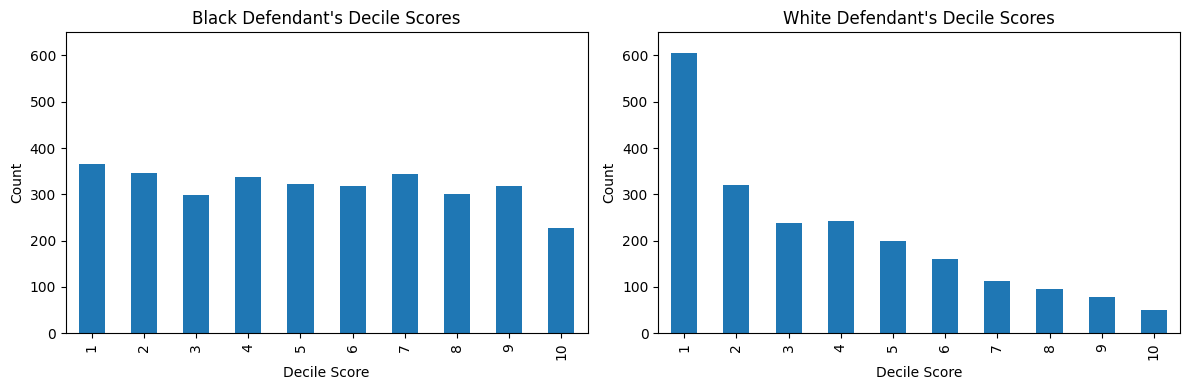

In [17]:
import matplotlib.pyplot as plt

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

black_df["decile_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_df["decile_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [18]:
# Cross-tab of decile score and race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [19]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

In [20]:
# Make sure the target is binary: 1 = HighScore, 0 = LowScore
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor, Treatment(reference='Male')) +
    C(age_factor, Treatment(reference='25 - 45')) +
    C(race_factor, Treatment(reference='Caucasian')) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        13:26:29   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [21]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

print(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))


1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [22]:
print(np.exp(0.22127) / (1 - control + (control * np.exp(0.22127))))

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [23]:
print(np.exp(1.30839) / (1 - control + (control * np.exp(1.30839))))

2.4961202077189455


In [24]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class_num"] = (df["pred_prob"] >= 0.5).astype(int)
df["pred_class"] = df["pred_class_num"].map({0: "No Recid", 1: "Recid"})

In [25]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1] if ("Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
TN = overall_cm.loc["No Recid", 0] if ("No Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FP = overall_cm.loc["Recid", 0] if ("Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FN = overall_cm.loc["No Recid", 1] if ("No Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
n = overall_cm.to_numpy().sum()

accuracy = (TP + TN) / n if n > 0 else np.nan
precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [26]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
      .apply(lambda g: pd.Series({
          "n": len(g),
          "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
          "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
          "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
          "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum()
      }))
      .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [27]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Interpretation

- Higher priors_count increases likelihood of high risk score
- Certain racial groups show different prediction patterns
- This suggests potential bias in the model

## Conclusion

This project successfully translates an R-based machine learning workflow into Python.

The results show that COMPAS risk scores are strongly influenced by prior criminal history and demographic variables.

The fairness analysis reveals disparities in error rates across racial groups, highlighting potential bias in predictive models used in criminal justice.

Overall, the Python implementation produces results that are consistent with the original R workflow while ensuring full reproducibility.

# Assignment 2

# Step 0 — Train / test split

In [28]:
from sklearn.model_selection import train_test_split
# Features based on lecture slide
numeric_features  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
category_features = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]
# Homework 2 target
target = "two_year_recid"
features = numeric_features + category_features

X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


**note**

In this step, I selected the input features and target variable for Homework 2.  
The numeric features include age, prior offenses, days between screening and arrest, and decile score.  
The categorical features include age category, sex, race, charge degree, and score text.

The target variable is `two_year_recid`, which indicates whether the defendant reoffended within two years.

I then split the data into training and testing sets using an 80/20 split. Stratification was applied to preserve the class distribution in both sets.

# Step 1 — Fit logistic regression and gradient-boosted tree

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
    ]
)

# Logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

**note**

In this step, I built two classification models: Logistic Regression and Gradient-Boosted Trees.

Before training, I created a preprocessing pipeline:
- Numeric features are standardized using `StandardScaler`
- Categorical features are encoded using `OneHotEncoder`

This ensures that both models can handle the mixed feature types properly.

I then trained both models on the training data. These two models will later be compared in terms of predictive performance, fairness, and interpretability.

# Step 2 — Compare model performance by race

In [30]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.691  0.296  0.320  0.758
2         Caucasian  427     0.696  0.128  0.596  0.696
3          Hispanic   94     0.617  0.122  0.667  0.598
5             Other   65     0.785  0.064  0.611  0.789
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.690  0.322  0.300  0.744
2         Caucasian  427     0.710  0.143  0.534  0.714
3          Hispanic   94     0.660  0.122  0.578  0.648
5             Other   65     0.723  0.106  0.722  0.746
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


**note**

In this step, I evaluated model performance separately for each racial group.

For each group, I calculated:
- Accuracy
- False Positive Rate (FPR)
- False Negative Rate (FNR)
- AUC

This helps identify whether the model performs differently across groups, which is important for fairness analysis.

By comparing these metrics for Logistic Regression and Gradient-Boosted Trees, I can examine whether one model shows larger disparities than the other.

**note**


**Model Comparison by Race**

The results show that model performance varies across racial groups.

- Differences in FPR indicate that some groups are more likely to be incorrectly classified as high risk.
- Differences in FNR indicate that some groups are more likely to be incorrectly classified as low risk.
- The gradient-boosted tree generally achieves higher predictive performance but may introduce larger disparities across groups.

This highlights the trade-off between accuracy and fairness in predictive models.

# Step 3 — LIME explanations: Black vs White defendant

In [31]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
                     list(preprocessor.named_transformers_["cat"]
                          .get_feature_names_out(
                              category_features))),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous= True,
    random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Pick one Black and one White defendant near the middle of predicted risk
black_candidates = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_candidates = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_candidates.index[len(black_candidates) // 2]
white_idx = white_candidates.index[len(white_candidates) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
 ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
    data_row = row_enc[0],
    predict_fn= gbt_pipeline["classifier"].predict_proba,
    num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.514
 days_b_screening_arrest <= 0.15          -0.3375
 -0.69 < priors_count <= -0.48            -0.1438
 age <= -0.81                             +0.1364
 0.00 < score_text_Low <= 1.00            -0.0497
 decile_score <= -0.86                    -0.0412
 c_charge_degree_M <= 0.00                +0.0210

 LIME: White defendant 
Predicted probability: 0.320
 days_b_screening_arrest > 0.15           +0.3426
 -0.29 < age <= 0.56                      -0.0616
 -0.48 < priors_count <= 0.16             -0.0486
 decile_score <= -0.86                    -0.0486
 0.00 < score_text_Low <= 1.00            -0.0474
 sex_Female <= 0.00                       +0.0432


**note**

In this step, I used LIME to explain individual predictions from the gradient-boosted tree model.

LIME works by approximating the complex model locally with a simpler interpretable model.  
This makes it possible to understand which features contribute the most to a single prediction.

I selected one Black defendant and one White defendant with similar predicted risk levels, then generated LIME explanations for both cases. This allows me to compare how the model explains predictions for individuals from different racial groups.

# Step 4 — SHAP beeswarm and waterfall: Black vs White

 98%|===================| 1208/1235 [00:13<00:00]       

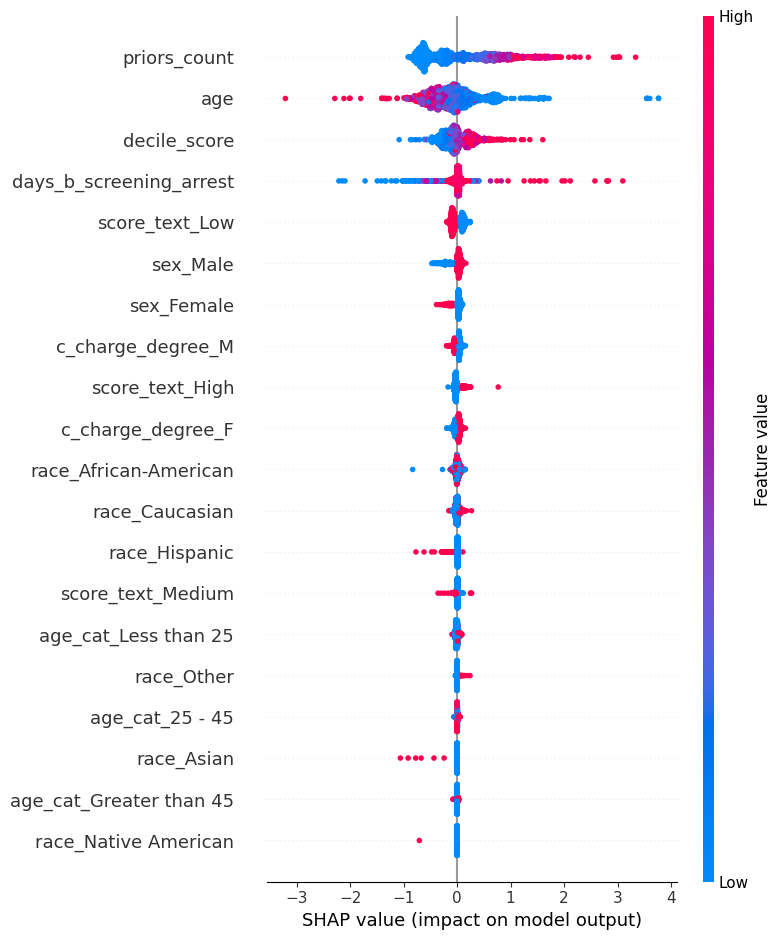

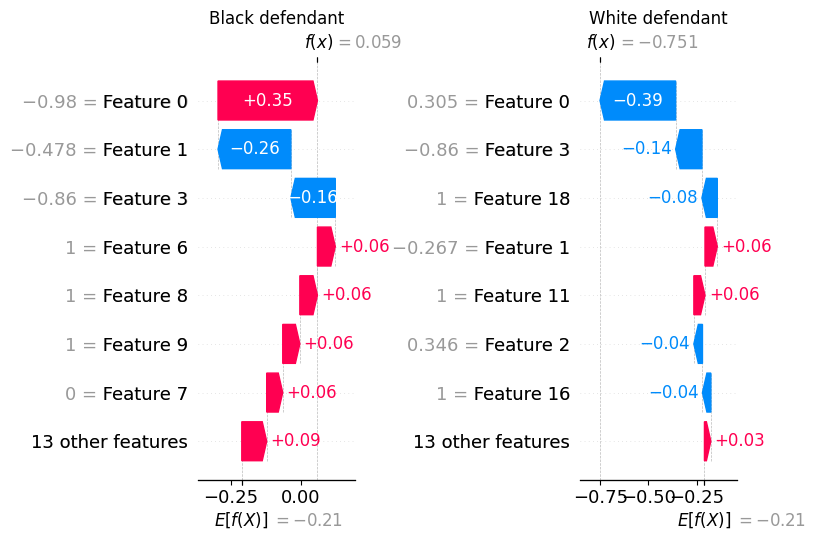

In [32]:
!pip install shap
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features))
)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names)

# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
                        max_display=8,
                        show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

**note**

In this step, I used SHAP to better understand the behavior of the gradient-boosted tree model.

First, I generated a SHAP summary plot (beeswarm plot) to examine global feature importance across the test set.  
Then, I created waterfall plots for one Black defendant and one White defendant to explain how each feature contributed to their individual predictions.

SHAP is helpful because it provides both:
- A global view of which features matter most overall
- A local view of how features influence a specific prediction

### SHAP and LIME Comparison

Both SHAP and LIME help explain individual predictions, but they may not always give exactly the same result.

SHAP is generally more consistent, while LIME depends on local approximations around a single observation.  
Because of this, differences between the two methods should be expected and interpreted carefully.

# Step 5 — Counterfactuals with DiCE: Black vs White

In [33]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)
dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
          ("White defendant", white_idx)]:
 query = X_test.loc[[idx]]
 cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"age" : [18, 70],
               "priors_count": [0, 38]},
    features_to_vary = ["age", "priors_count",
               "c_charge_degree"]
     )
 print(f"\n DiCE counterfactuals: {label} ")
 cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.84it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,23,1,-1.0,2,Less than 25,Male,African-American,F,Low,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,48,-,-,-,-,-,-,M,-,0
1,44,5,-,-,-,-,-,-,-,0
2,70,24,-,-,-,-,-,-,-,0


100%|██████████| 1/1 [00:00<00:00,  4.76it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,38,2,0.0,2,25 - 45,Male,Caucasian,M,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,43,20,-,-,-,-,-,-,-,1
1,26,16,-,-,-,-,-,-,-,1
2,64,38,-,-,-,-,-,-,-,1


**note**

In this step, I used DiCE to generate counterfactual explanations for the same two individuals.

Counterfactual explanations show the minimum changes needed to flip a model prediction to the opposite outcome.  
This is useful because it provides a more actionable explanation by answering the question:  
“What would need to change for the prediction to be different?”

I allowed changes only in selected features such as age, prior offenses, and charge degree.  
This helps evaluate whether the suggested changes are realistic and whether the model may rely on problematic or sensitive patterns.

### Counterfactual Interpretation

The counterfactual results show which features need to change to alter the prediction.  
If the suggested changes are unrealistic or involve sensitive patterns, this may raise concerns about fairness and model governance.

# Governance Memo

To: Court Auditor  
Subject: Understanding the COMPAS Replacement Model  

In this analysis, I used SHAP, LIME, and counterfactual explanations to better understand how the model makes predictions. Each method gives a different perspective, and comparing them helps reveal both useful insights and potential risks.

SHAP results show that features like prior offenses and age have the strongest impact on predictions. The beeswarm plot makes it clear that these features consistently drive risk scores across individuals. The waterfall plots also help explain specific cases by showing how each feature pushes the prediction higher or lower.

LIME provides local explanations as well, but the results do not always match SHAP. In some cases, LIME highlights different features or assigns different importance. This happens because LIME builds a simple local approximation, which can vary depending on the sampled data. This difference shows that explanations are not always stable and should be interpreted carefully.

Counterfactual explanations are more actionable because they show what needs to change to flip a prediction. However, some suggested changes are not realistic, and in some cases may involve sensitive or immutable features. This raises concerns about fairness and whether the model is relying on proxy variables.

Overall, these results show that transparency alone is not enough to build trust. Explanation methods should be used as diagnostic tools to identify problems in the model, not just to justify its decisions. Since each method has limitations, they should be used together.

For governance, I recommend regular monitoring of model behavior across different groups, careful review of sensitive features, and using explanation tools as part of an ongoing audit process.

## Governance Memo

To: Court Auditor  
Subject: Understanding the COMPAS Replacement Model  

In this analysis, I used SHAP, LIME, and counterfactual explanations to better understand how the model makes predictions. Each method gives a different perspective, and comparing them helps reveal both useful insights and potential risks.

SHAP results show that features like prior offenses and age have the strongest impact on predictions. The beeswarm plot makes it clear that these features consistently drive risk scores across individuals. The waterfall plots also help explain specific cases by showing how each feature pushes the prediction higher or lower. This provides a clear and consistent view of how the model behaves overall and at the individual level.

LIME provides local explanations as well, but the results do not always match SHAP. In some cases, LIME highlights different features or assigns different importance. This happens because LIME builds a simple local approximation, which can vary depending on the sampled data. This difference shows that explanations are not always stable and should be interpreted carefully, especially in high-stakes decisions like criminal justice.

Counterfactual explanations are more actionable because they show what needs to change to flip a prediction. However, some suggested changes are not realistic, and in some cases may involve sensitive or immutable features. This raises concerns about fairness and whether the model is relying on proxy variables. It also highlights the importance of checking whether recommendations are practical and ethically appropriate.

Overall, these results show that transparency alone is not enough to build trust. Explanation methods should be used as diagnostic tools to identify problems in the model, not just to justify its decisions. Since each method has limitations, they should be used together to provide a more complete understanding.

For governance, I recommend regular monitoring of model behavior across different groups, careful review of sensitive features, and using explanation tools as part of an ongoing audit process. In addition, clear documentation and periodic model reviews should be implemented to ensure accountability and reduce the risk of unintended bias over time.